In [1]:
library(parallel)
library(GenomicFeatures)
set.seed(1234)
library(repr)
library(motifmatchr)
library(fastmatch)
library(qlcMatrix)

library(ensembldb)
library(EnsDb.Hsapiens.v86)
library(AnnotationFilter)

library(Signac)
library(Seurat)
library(JASPAR2024)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg38)
library(patchwork)
library(ggplot2)
library(Matrix)
library(zoo)
library(tidyr)

source("../multiome_methods/function_calls.r")
source("../multiome_methods/peak_gene_relations.r")
source("../multiome_methods/binding_site_identification.r")
source("../multiome_methods/TF_activity.r")
source("../multiome_methods/signac_utils.r")

library(dplyr)

library(ggplot2)
library(hexbin)
library(RColorBrewer)
library(cowplot)
library(gridExtra)
library(ggExtra)

library(pheatmap)
library(purrr)
library(data.table)
library(Rsamtools)
library(stringi)


Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

### healthy breast

In [2]:
healthy_breast <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1775807036776_d857c27f-aa86-455a-8f71-f5875450a996/kackhaufen1/global_motif_analysis.rds")

In [6]:
DefaultAssay(object = healthy_breast) <- "peaks"

In [10]:
frag_path <- "~/swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"
frag_obj <- CreateFragmentObject(
        path = frag_path,
        cells = colnames(healthy_breast)   # restrict to cells in this object
        )
healthy_breast[["peaks"]]@fragments <- list(frag_obj)

Computing hash



In [17]:
str(Motifs(healthy_breast))

Formal class 'Motif' [package "Signac"] with 5 slots
  ..@ data       :Formal class 'lgCMatrix' [package "Matrix"] with 6 slots
  .. .. ..@ i       : int [1:9670656] 5 83 116 125 192 331 460 543 549 594 ...
  .. .. ..@ p       : int [1:721] 0 4499 15659 22512 34203 47253 58466 72692 146668 192772 ...
  .. .. ..@ Dim     : int [1:2] 165040 720
  .. .. ..@ Dimnames:List of 2
  .. .. .. ..$ : chr [1:165040] "chr1-9949-10530" "chr1-17247-17528" "chr1-88077-88293" "chr1-180659-181625" ...
  .. .. .. ..$ : chr [1:720] "MA0069.1" "MA0071.1" "MA0074.1" "MA0101.1" ...
  .. .. ..@ x       : logi [1:9670656] TRUE TRUE TRUE TRUE TRUE TRUE ...
  .. .. ..@ factors : list()
  ..@ pwm        :List of 720
  .. ..$ MA0069.1: int [1:4, 1:14] 2 4 4 33 2 2 0 39 4 26 ...
  .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. ..$ : chr [1:4] "A" "C" "G" "T"
  .. .. .. ..$ : NULL
  .. ..$ MA0071.1: int [1:4, 1:10] 15 1 2 7 9 1 0 15 6 12 ...
  .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. ..$ : chr [1:4] "A

In [18]:
# gather the footprinting information for sets of motifs
healthy_breast <- Signac::Footprint(
  object = healthy_breast,
  motif.name = c("MA0103.4", "MA0139.2"),
  genome = BSgenome.Hsapiens.UCSC.hg38
)

# plot the footprint data for each group of cells
p2 <- Signac::PlotFootprint(healthy_breast, features = c("MA0103.4", "MA0139.2"))

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites



In [ ]:
options(repr.plot.width=20, repr.plot.height=10)

Warning message:
"Removed 5060 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."
Warning message:
"Removed 5150 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


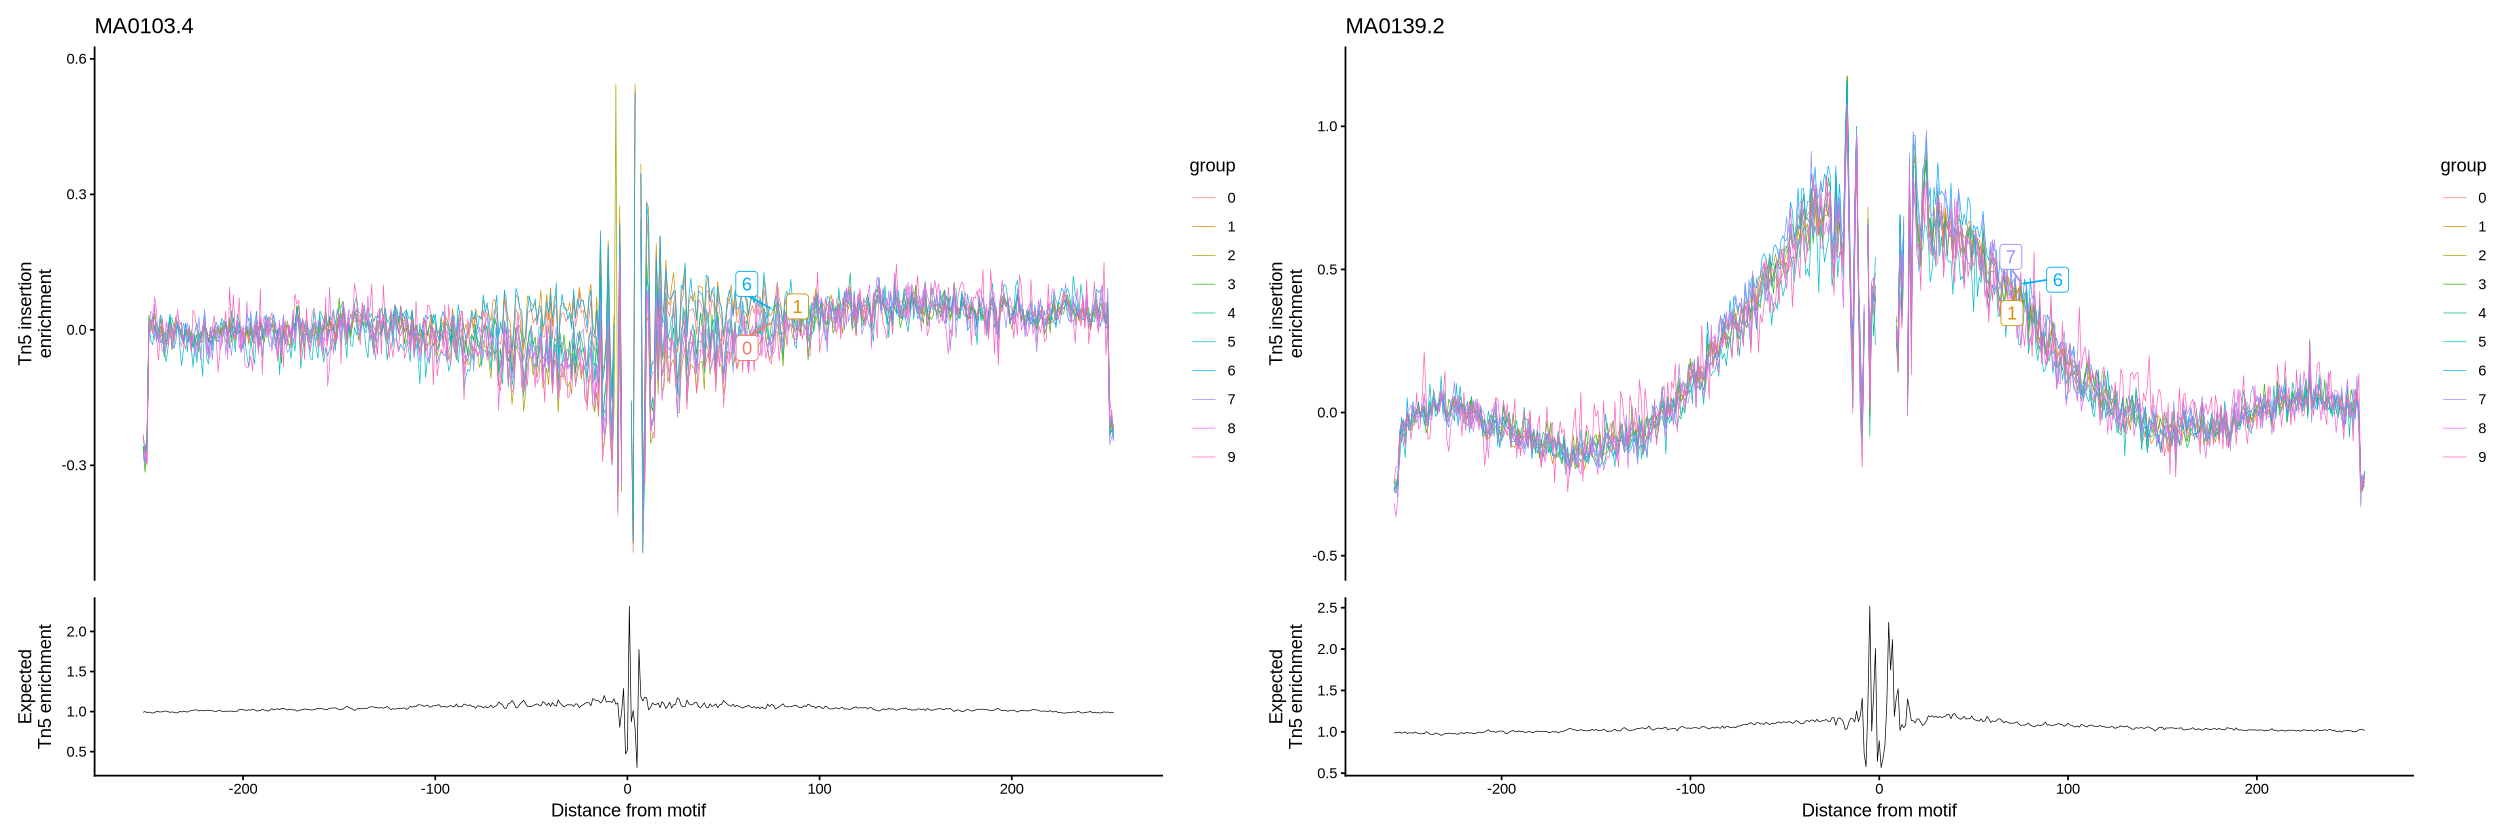

In [19]:
p2

In [20]:

# gather the footprinting information for sets of motifs
healthy_breast <- Signac::Footprint(
  object = healthy_breast,
  motif.name = c("MA0652.2", "MA0102.5"),
  genome = BSgenome.Hsapiens.UCSC.hg38
)

# plot the footprint data for each group of cells
p2 <- Signac::PlotFootprint(healthy_breast, features = c("MA0652.2", "MA0102.5"))

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites



Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5130 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."
Warning message:
"Removed 5100 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


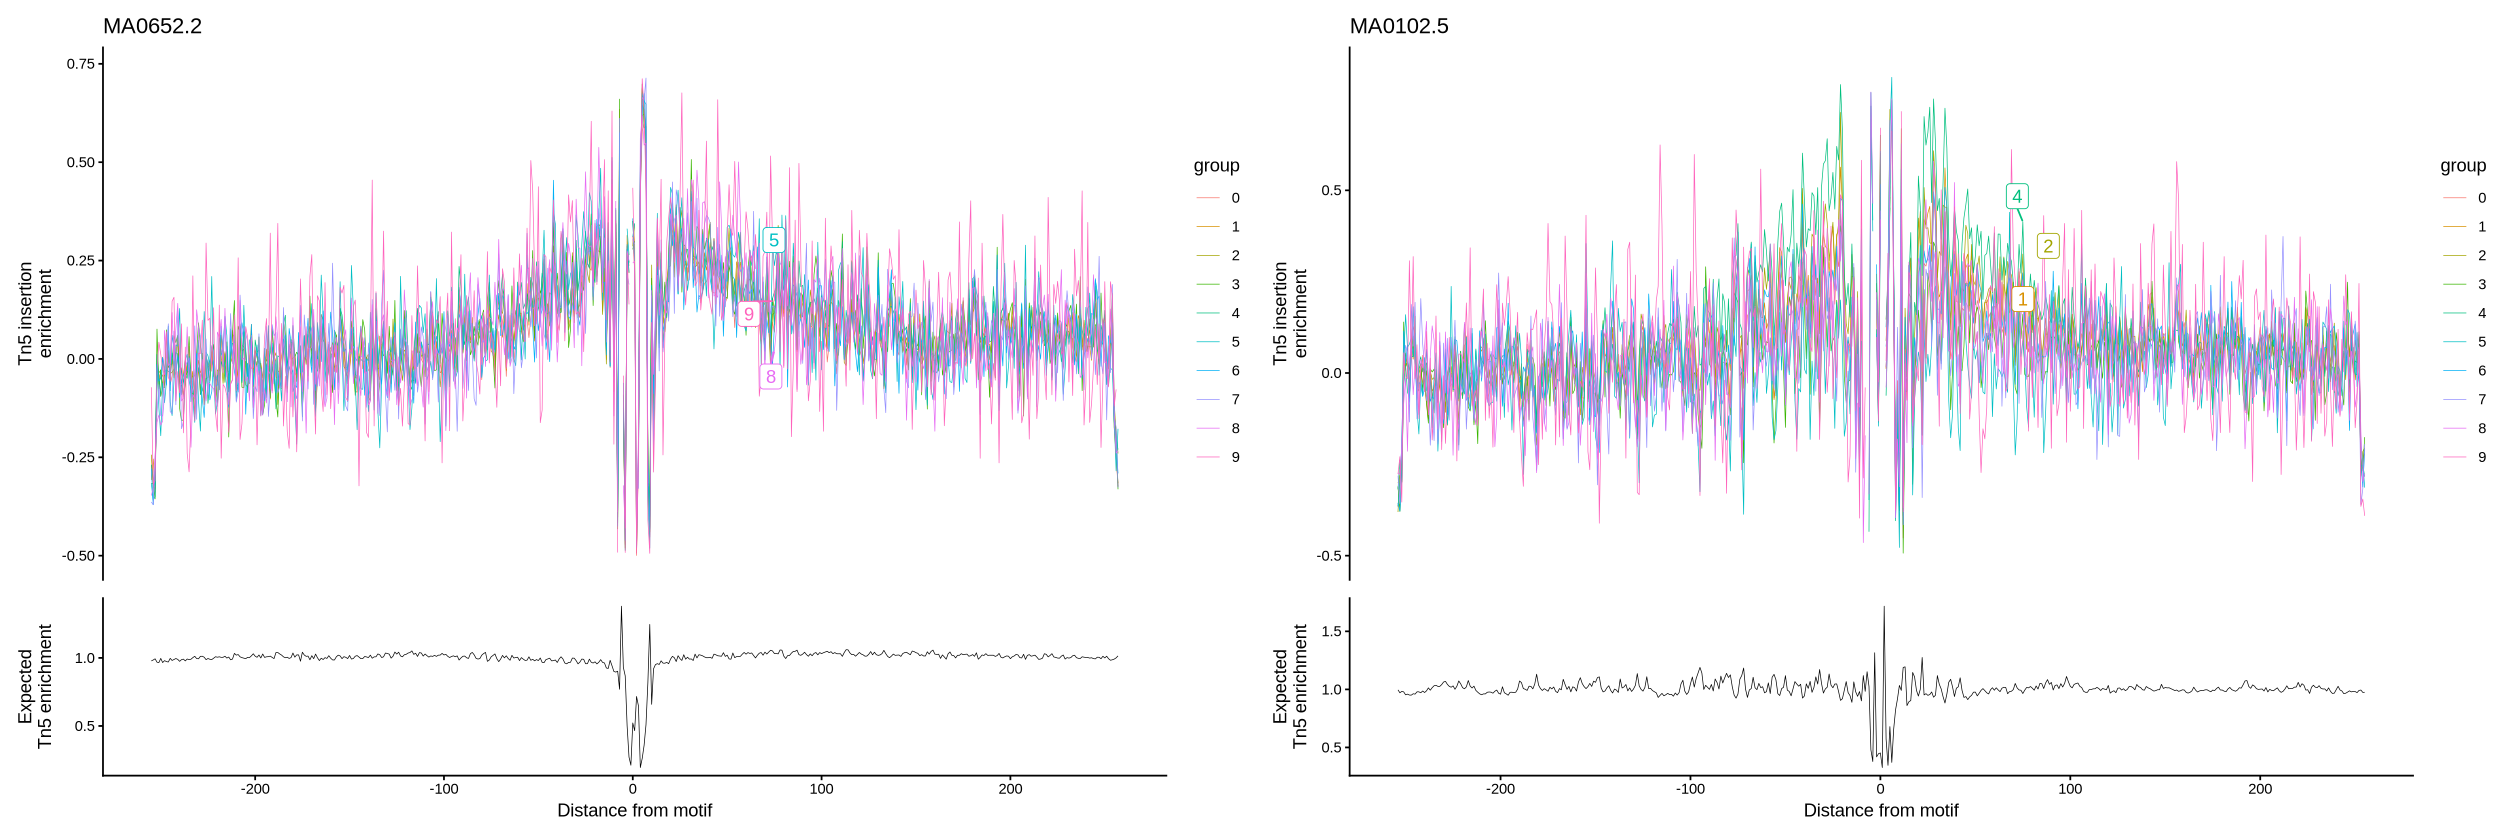

In [21]:
p2

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5070 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."
Warning message:
"Removed 5100 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."
Warning message:
"Removed 5110 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


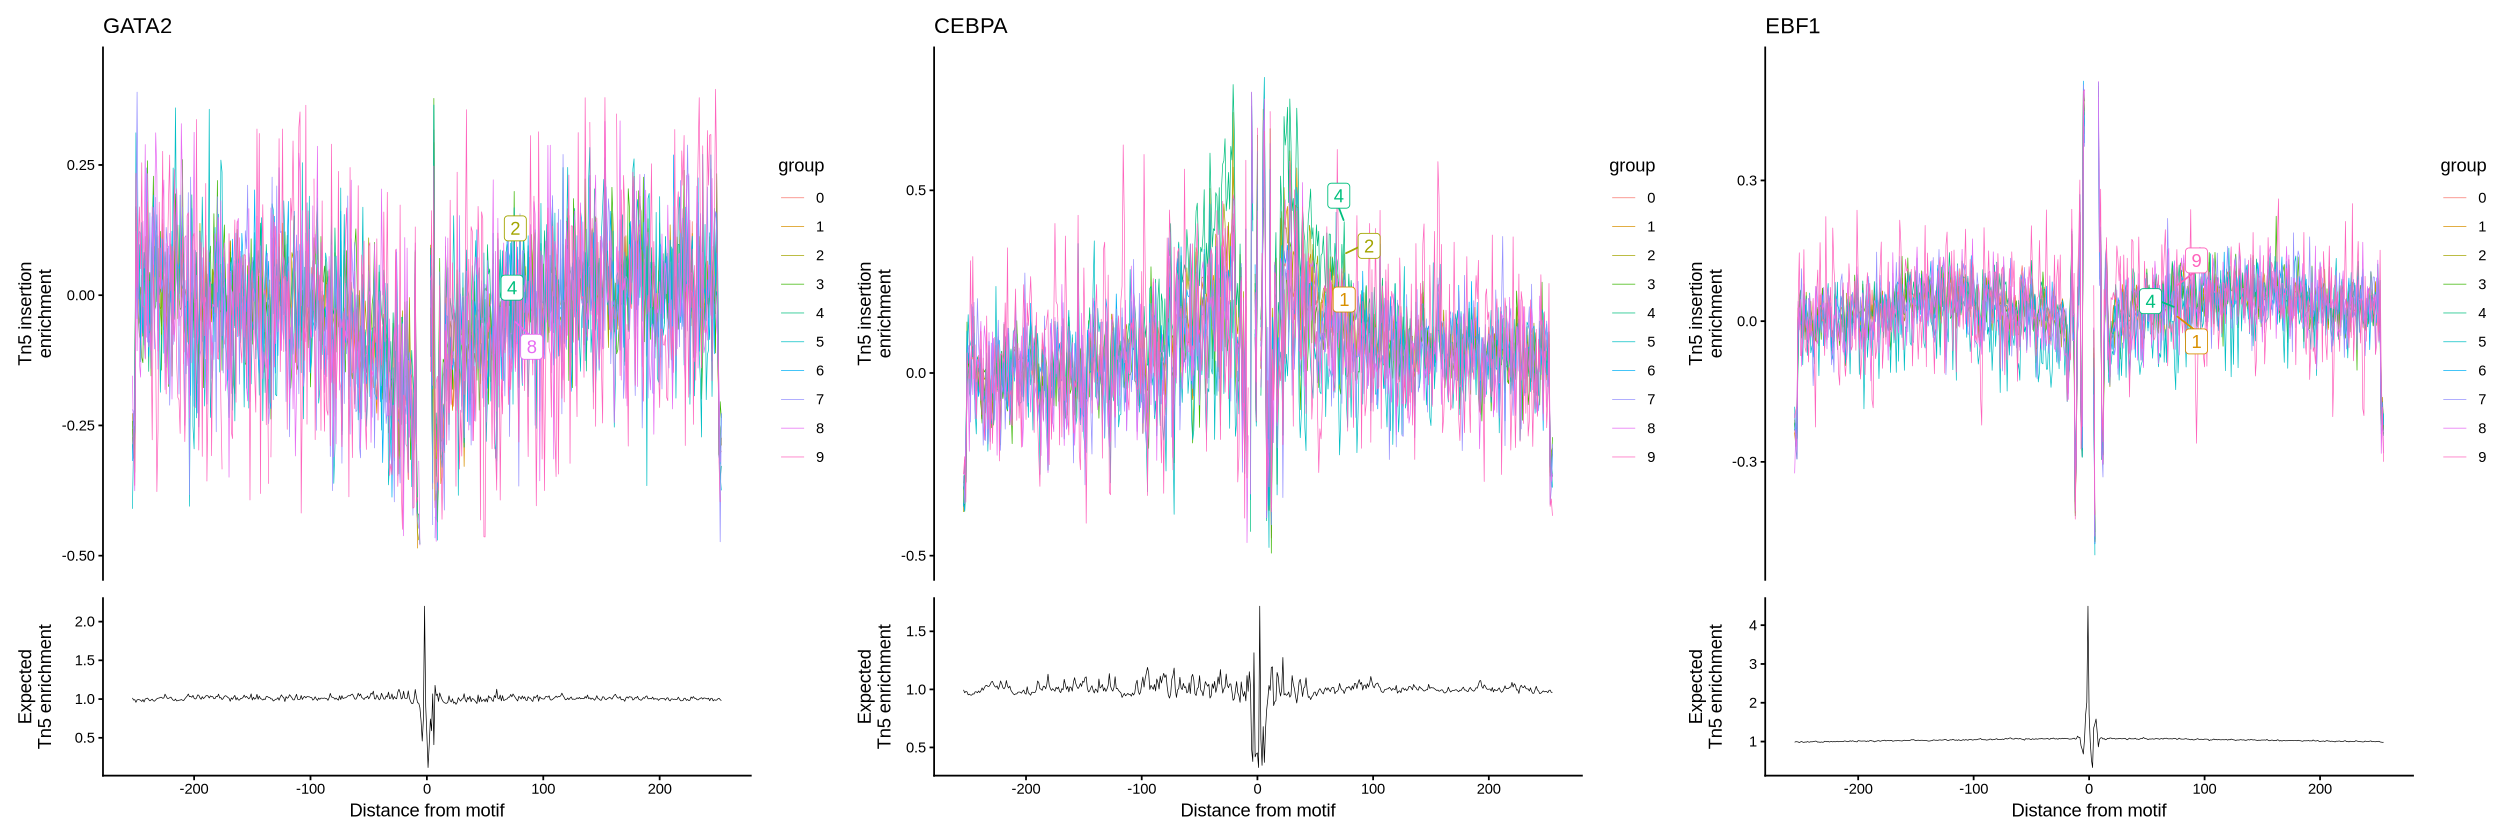

In [14]:
p2

### heart AVN

In [25]:
AVN <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_heart_cellatlas_final_anno_w_footp1775766898716_mopitas/plasmidpoop/global_motif_analysis.rds")

In [2]:
AVN <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1776009725832_mopitas_hvg_ctg_mygenes_celltg/junkDNA420/global_motif_analysis.rds")

In [3]:
DefaultAssay(object = AVN) <- "peaks"

In [27]:
AVN

An object of class Seurat 
612284 features across 8358 samples within 5 assays 
Active assay: peaks (126746 features, 126741 variable features)
 2 layers present: counts, data
 4 other assays present: RNA, SCT, ATAC, chromvar
 5 dimensional reductions calculated: pca_sct, pca_rna, lsi, umap_RNA_peaks, umap_SCT_peaks

In [4]:
frag_path <- "~/swarm/backend/data/cell_atlas/HCAHeartST11350194_HCAHeartST11445771_atac_fragments.tsv.gz"
frag_obj <- CreateFragmentObject(
        path = frag_path,
        cells = colnames(AVN)   # restrict to cells in this object
        )
AVN[["peaks"]]@fragments <- list(frag_obj)

Computing hash



In [ ]:
colnames(AVN@meta.data)

[1] "orig.ident"                  "nCount_RNA"                 
 [3] "nFeature_RNA"                "sangerID"                   
 [5] "combinedID"                  "donor"                      
 [7] "donor_type"                  "region"                     
 [9] "region_finest"               "age"                        
[11] "gender"                      "facility"                   
[13] "cell_or_nuclei"              "modality"                   
[15] "kit_10x"                     "flushed"                    
[17] "n_genes"                     "n_genes_by_counts"          
[19] "total_counts"                "total_counts_mt"            
[21] "pct_counts_mt"               "total_counts_ribo"          
[23] "pct_counts_ribo"             "scrublet_score"             
[25] "scrublet_leiden"             "cluster_scrublet_score"     
[27] "doublet_pval"                "doublet_bh_pval"            
[29] "batch_key"                   "leiden_scVI"                
[31] "cell_type"                   "cell_state_HCAv1"           
[33] "cell_state_scNym"            "cell_state_scNym_confidence"
[35] "cell_state"                  "latent_RT_efficiency"       
[37] "latent_cell_probability"     "latent_scale"               
[39] "n_counts"                    "_scvi_batch"                
[41] "_scvi_labels"                "clus20"                     
[43] "doublet_cls"                 "original_or_new"            
[45] "batch"                       "scANVI_predictions"         
[47] "leiden_scArches"             "peak_sangerID"              
[49] "peak_combinedID"             "peak_donor"                 
[51] "peak_donor_type"             "peak_region"                
[53] "peak_region_finest"          "peak_age"                   
[55] "peak_gender"                 "peak_facility"              
[57] "peak_cell_or_nuclei"         "peak_modality"              
[59] "peak_kit_10x"                "peak_flushed"               
[61] "peak_batch_key"              "peak_cell_type"             
[63] "peak_cell_state"             "nCount_Peaks"               
[65] "nFeature_Peaks"              "percent.mt"                 
[67] "nucleosome_signal"           "nucleosome_percentile"      
[69] "TSS.enrichment"              "TSS.percentile"             
[71] "nCount_peaks_macs2"          "nFeature_peaks_macs2"       
[73] "nCount_SCT"                  "nFeature_SCT"               
[75] "RNA.weight"                  "peaks.weight"               
[77] "RNA_peaks_clusters_res0.1"   "RNA_peaks_clusters_res0.2"  
[79] "SCT.weight"                  "SCT_peaks_clusters_res0.2"  
[81] "SCT_peaks_clusters_res0.1"   "nCount_ATAC"                
[83] "nFeature_ATAC"               "nCount_peaks"               
[85] "nFeature_peaks"

In [8]:
AVN$is_fibroblast <- AVN$cell_type == "Fibroblast"

In [11]:
Idents(AVN)<-"is_fibroblast"

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
"Removed 1018 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


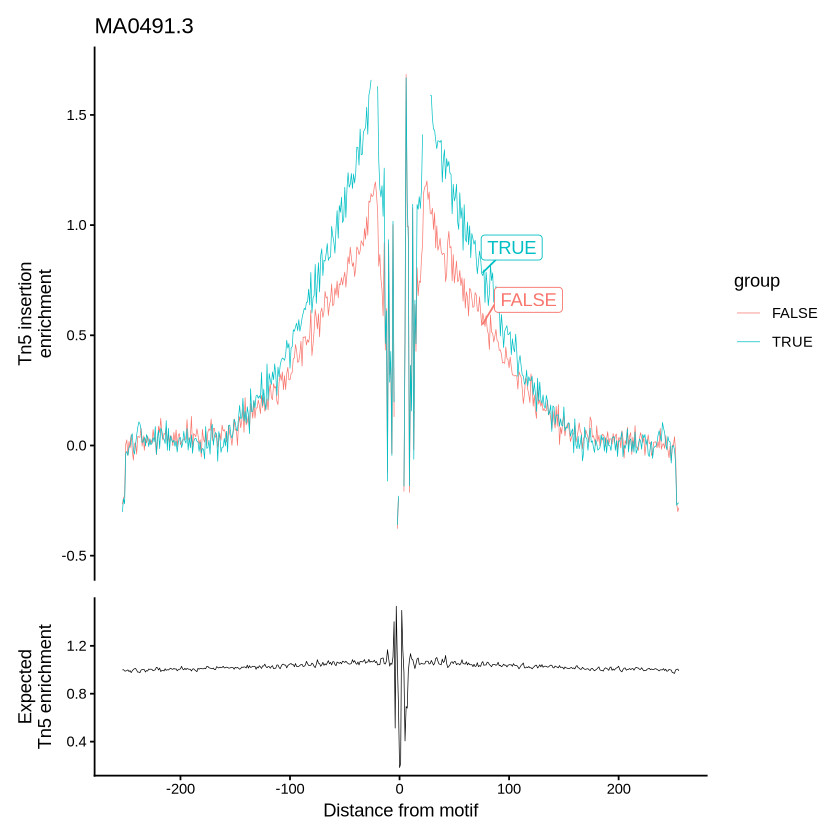

In [14]:

# gather the footprinting information for sets of motifs
AVN <- Signac::Footprint(
  object = AVN,
  motif.name = c("MA0491.3"),
  genome = BSgenome.Hsapiens.UCSC.hg38
)

# plot the footprint data for each group of cells
Signac::PlotFootprint(AVN, features = c("MA0491.3"))


Computing observed Tn5 insertions per base



Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
"Removed 1022 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


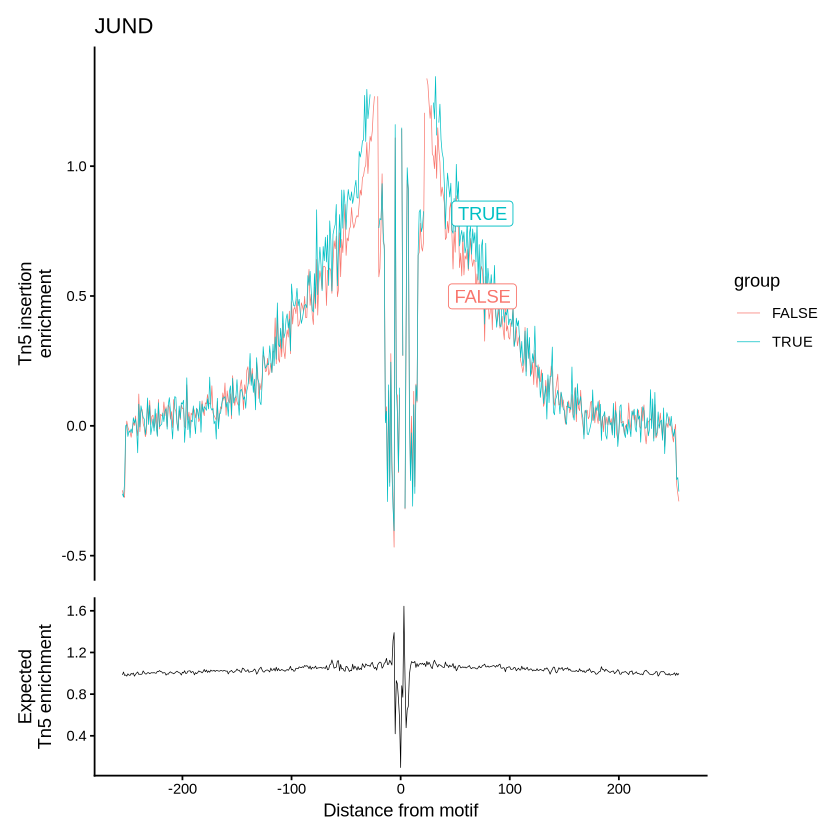

In [13]:

# gather the footprinting information for sets of motifs
AVN <- Signac::Footprint(
  object = AVN,
  motif.name = c("JUND"),
  genome = BSgenome.Hsapiens.UCSC.hg38
)

# plot the footprint data for each group of cells
Signac::PlotFootprint(AVN, features = c("JUND"))


Warning message:
"Removed 508 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5600 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


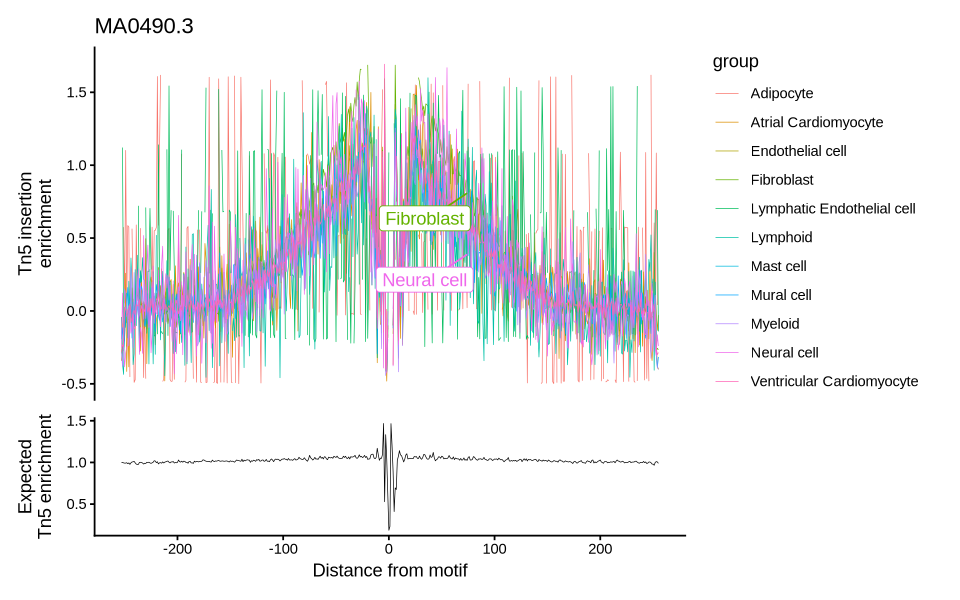

In [21]:

Signac::PlotFootprint(
  AVN,
  features = "MA0490.3",
  group.by = "cell_type",
  label = TRUE
)

In [19]:
AVN$fibro_group <- ifelse(
  AVN$cell_type == "Fibroblast",
  "Fibroblast",
  "Non-Fibroblast cells"
)

p <- Signac::PlotFootprint(
  AVN,
  features = "MA0490.3",
  group.by = "fibro_group",
  label = TRUE
)

Warning message:
"Removed 1018 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


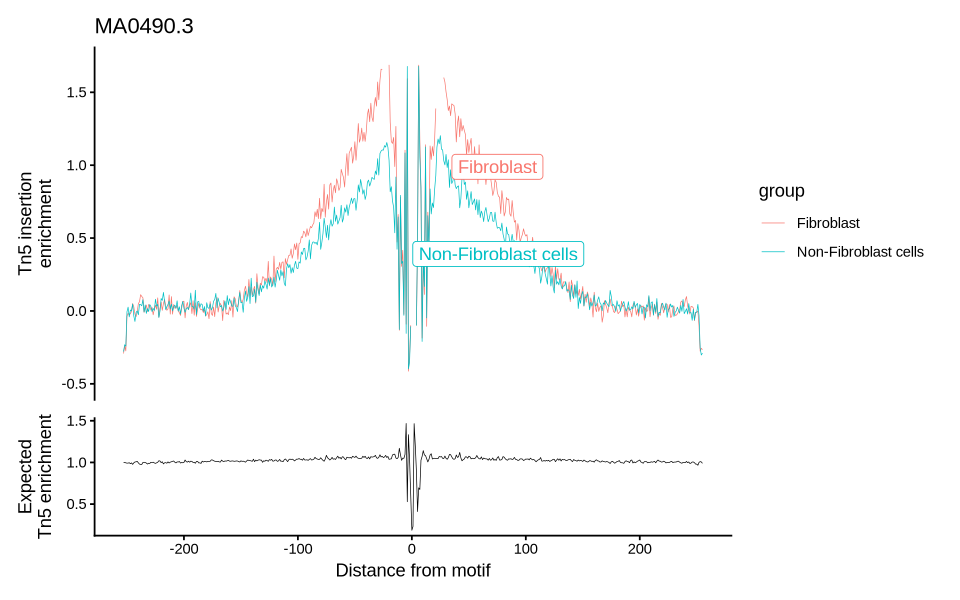

In [20]:
p + ggplot2::scale_color_manual(
  values = c("Fibroblast" = "red", "Non-Fibroblast cells" = "lightblue")
)

In [ ]:
# change plot size
options(repr.plot.width=8, repr.plot.height=5)
Signac::PlotFootprint(AVN, features = c("MA0490.3"), colors = c("lightblue", "red"),label = {TRUE: "Fibroblast", FALSE: "Non-Fibroblast cells"})

ERROR: Error in Signac::PlotFootprint(AVN, features = c("MA0490.3"), colors = c("lightblue", : unused argument (colors = c("lightblue", "red"))


Warning message:
"Removed 1022 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."
Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
"Removed 1018 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


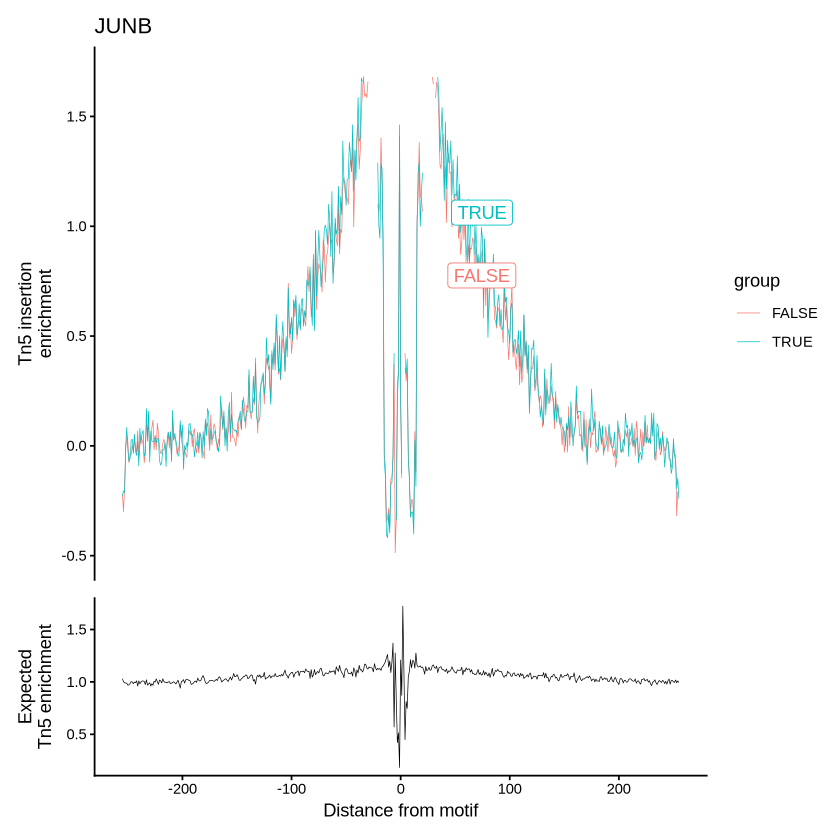

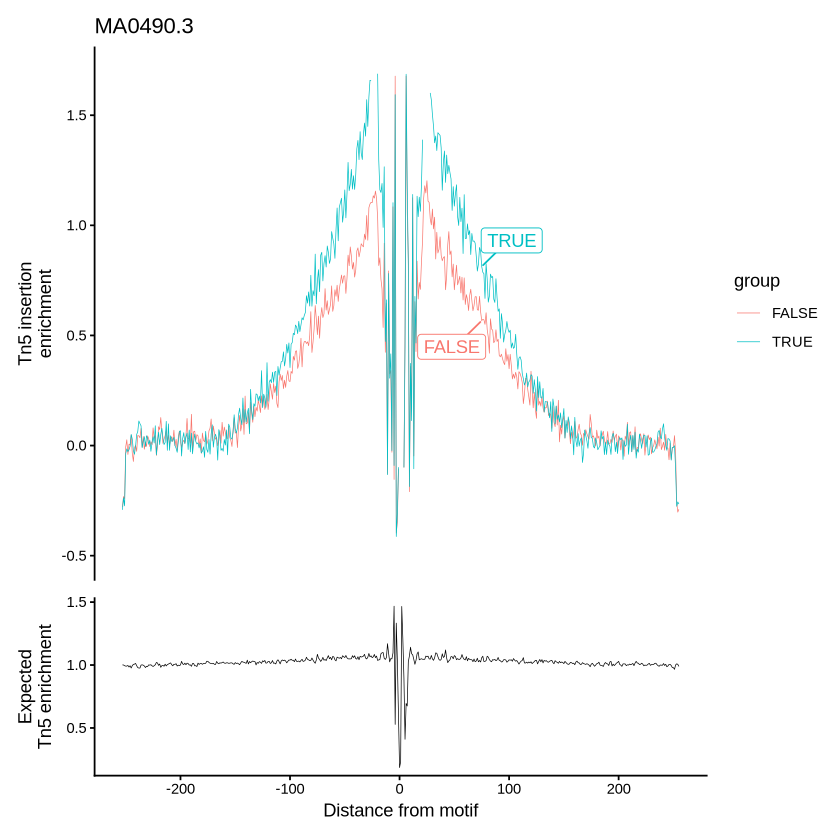

In [16]:

# plot the footprint data for each group of cells
Signac::PlotFootprint(AVN, features = c("JUNB"))
# plot the footprint data for each group of cells
AVN <- Signac::Footprint(
  object = AVN,
  motif.name = c("MA0490.3"),
  genome = BSgenome.Hsapiens.UCSC.hg38
)
Signac::PlotFootprint(AVN, features = c("MA0490.3"))


In [ ]:

# gather the footprinting information for sets of motifs
AVN <- Signac::Footprint(
  object = AVN,
  motif.name = c("JUNB"),
  genome = BSgenome.Hsapiens.UCSC.hg38
)

# plot the footprint data for each group of cells
Signac::PlotFootprint(AVN, features = c("JUNB"))


In [11]:
Idents(AVN)<-"cell_type"

In [19]:
table(AVN@meta.data$cell_or_nuclei)


Nuclei 
  8358 

Computing observed Tn5 insertions per base



Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
"Removed 504 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5578 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


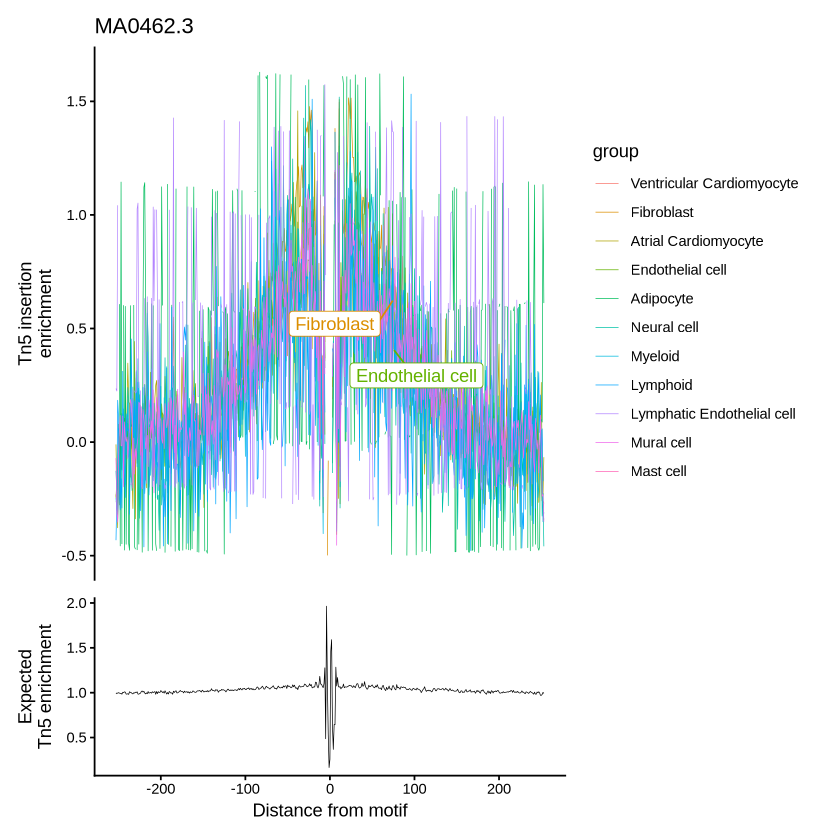

In [15]:

# gather the footprinting information for sets of motifs
AVN <- Signac::Footprint(
  object = AVN,
  motif.name = c("MA0462.3"),
  genome = BSgenome.Hsapiens.UCSC.hg38
)

# plot the footprint data for each group of cells
Signac::PlotFootprint(AVN, features = c("MA0462.3"))


## before 

In [36]:

# gather the footprinting information for sets of motifs
AVN <- Signac::Footprint(
  object = AVN,
  motif.name = c("MA0477.3", "MA1128.2", "MA1136.1", "MA1952.2"),
  genome = BSgenome.Hsapiens.UCSC.hg38
)


Computing observed Tn5 insertions per base



Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites



Warning message:
"Removed 508 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5600 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."
Warning message:
"Removed 511 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5599 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


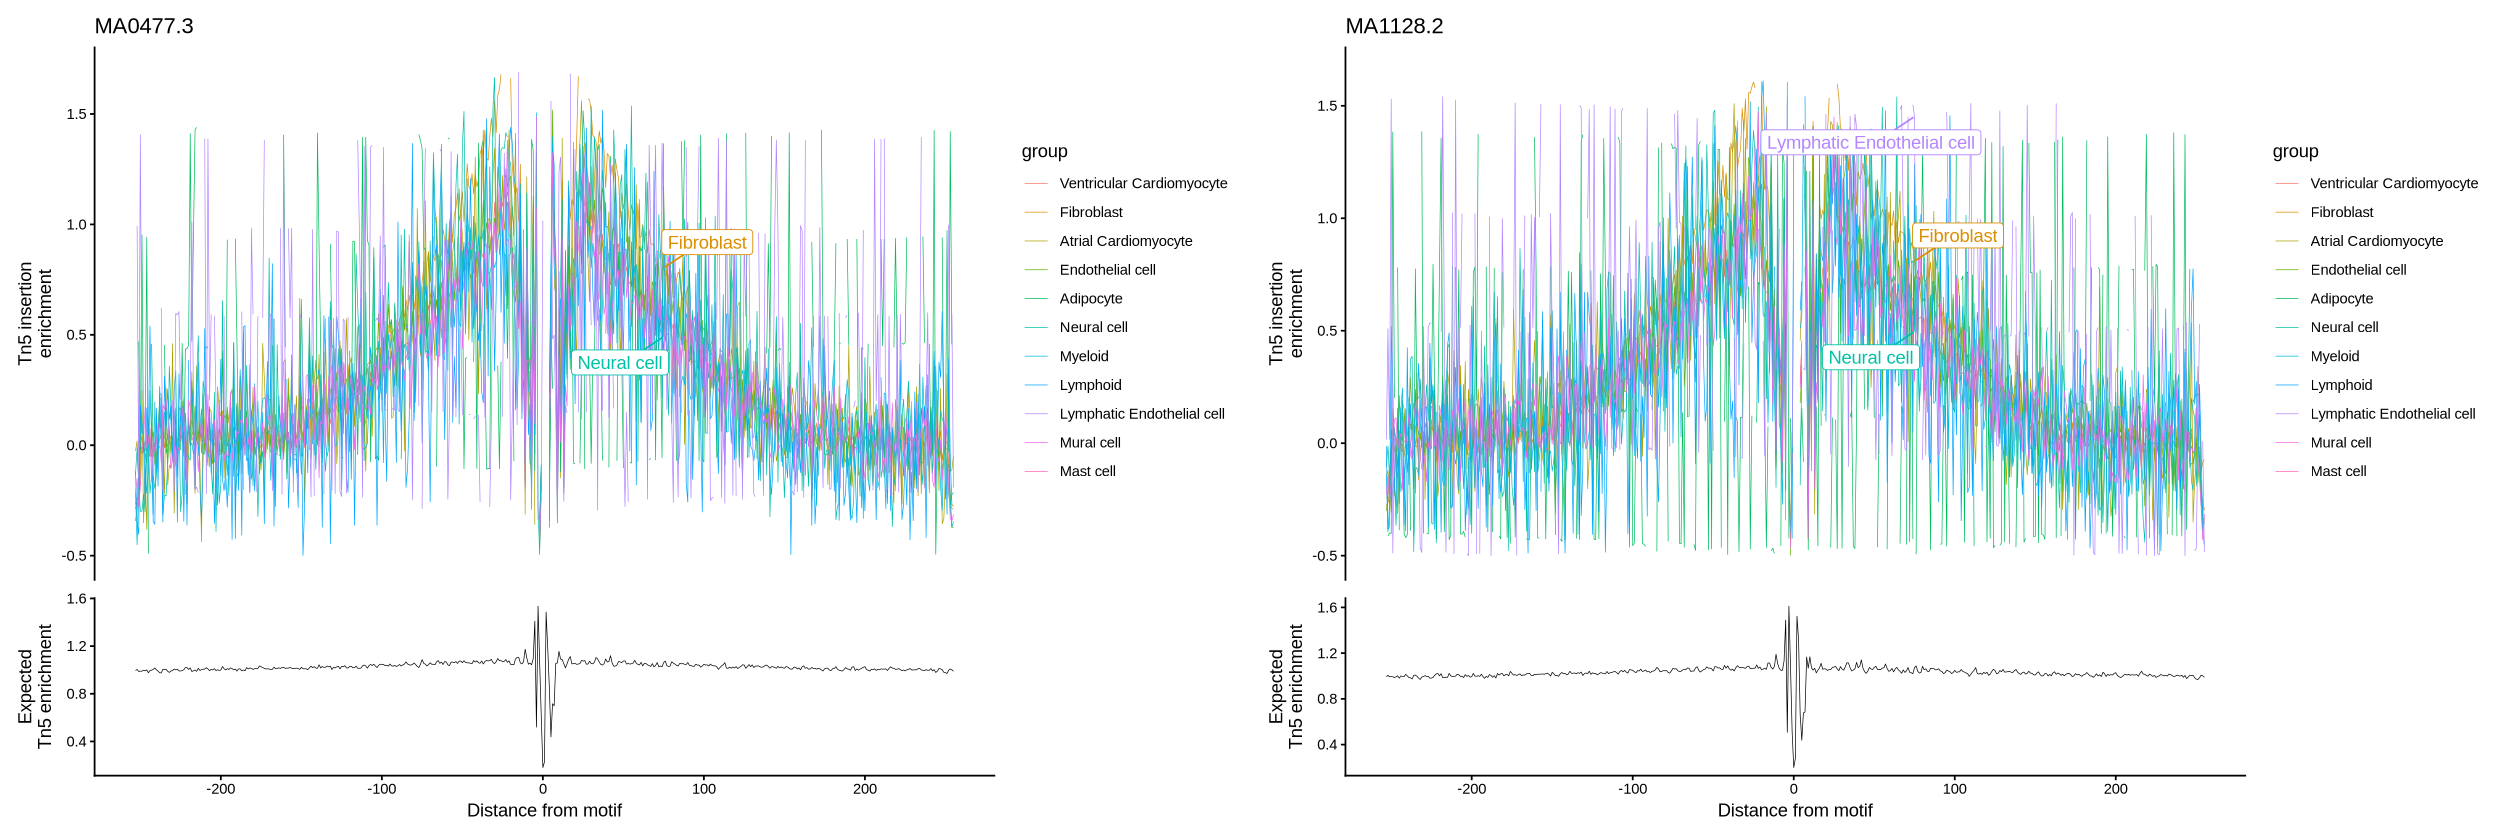

In [38]:

# plot the footprint data for each group of cells
Signac::PlotFootprint(AVN, features = c("MA0477.3", "MA1128.2"))

Warning message:
"Removed 510 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5610 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."
Warning message:
"Removed 386 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5622 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


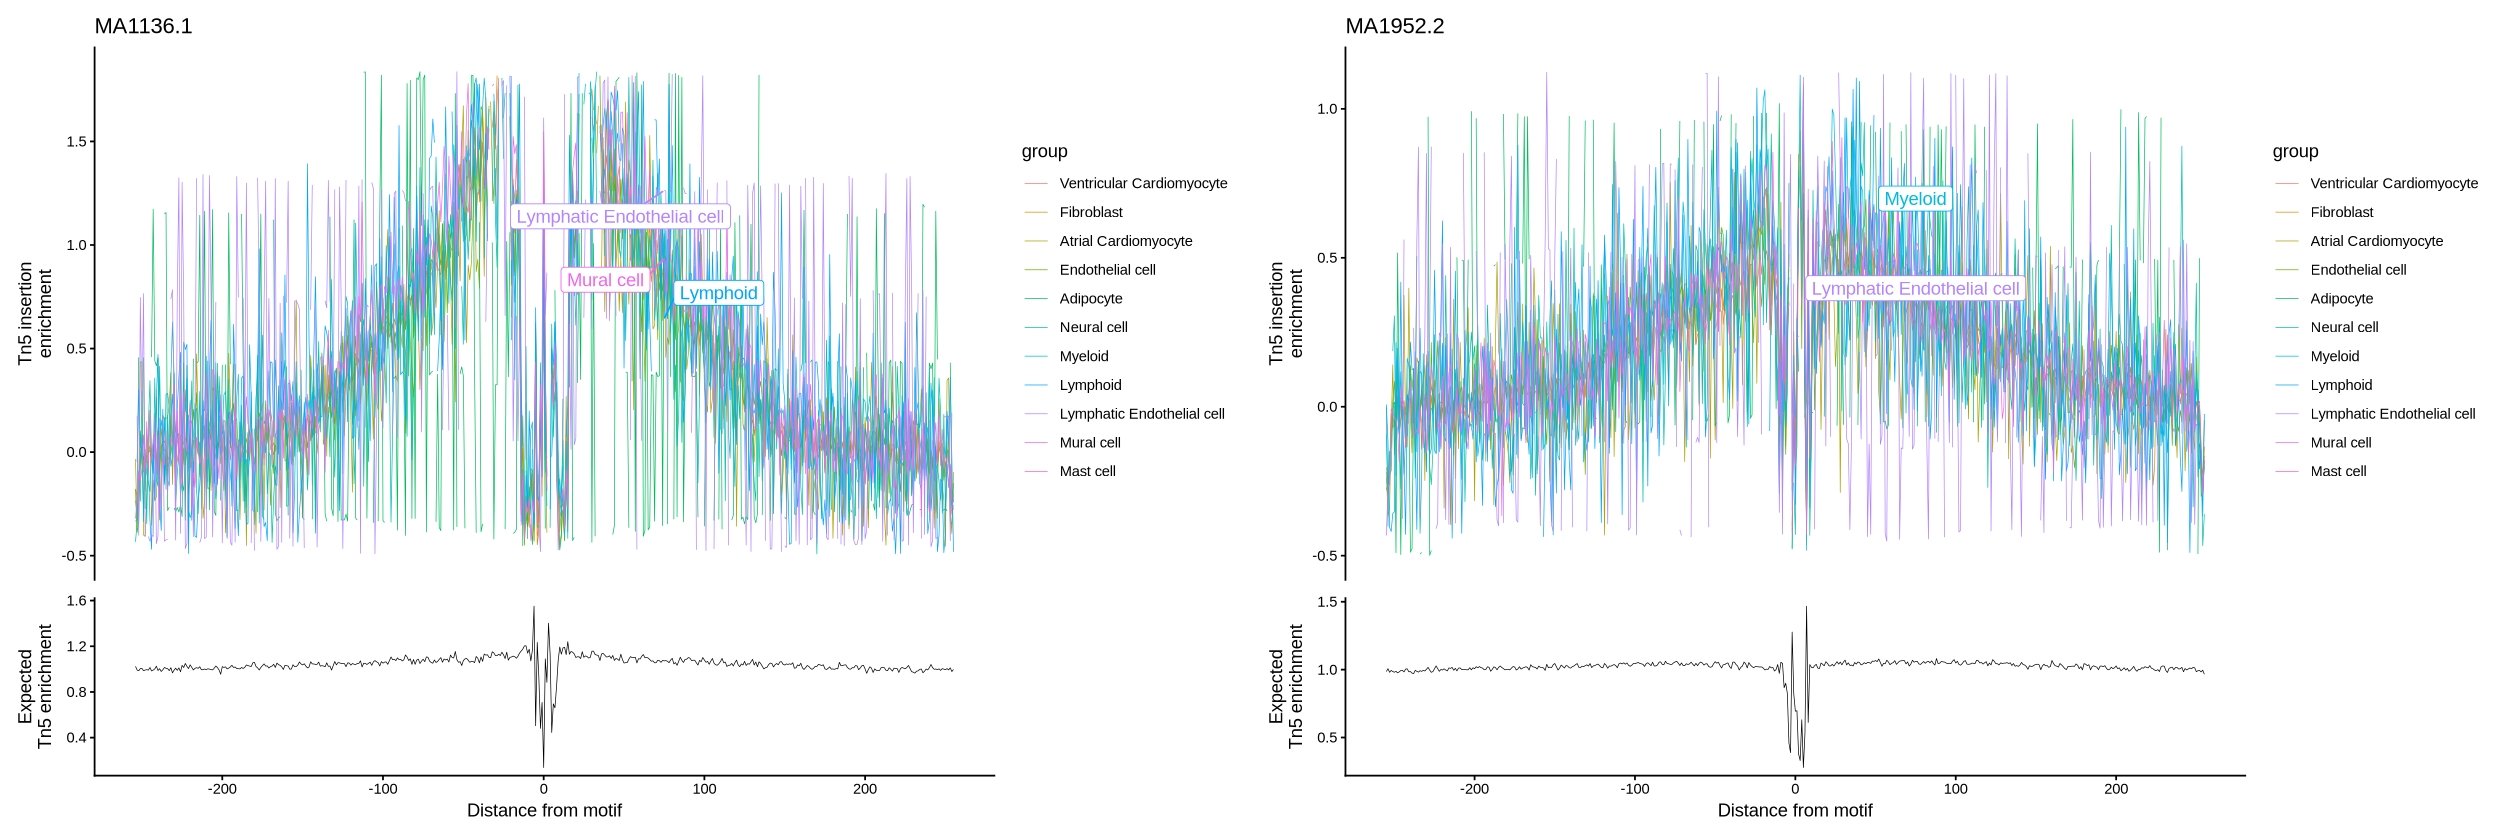

In [39]:
# plot the footprint data for each group of cells
Signac::PlotFootprint(AVN, features = c("MA1136.1", "MA1952.2"))

In [2]:
test_multiome =readRDS("/nfs/home/students/m.back/swarm/backend/data/cell_atlas/renamed_genes/HCAHeartST11350194_HCAHeartST11445771_heart_cell_atlas_preprocessed.rds")


In [ ]:
/workspaces/swarm/backend/data/cell_atlas/renamed_genes/HCAHeartST11350194_HCAHeartST11445771_heart_cell_atlas_preprocessed.rds




In [5]:
test_multiome[["RNA"]]

Assay (v5) data with 32724 features for 8358 cells
Top 10 variable features:
 F13A1, NPPA, LINC01411, NRXN1, KCNT2, NPPB, XKR4, GPC5, AC016766.1,
LINC02388 
Layers:
 counts, data, scale.data 